# 03 Backtest: Regime-Rule Strategy

Walk-forward backtest on the last 20% of the dataset (matching the modelling test slice). The rule: take a trade only if the model says win probability is high enough AND the regime is not in the exclusion set. Compared against the take-everything baseline.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_trades, load_sentiment
from src.features import attach_sentiment, add_trade_features, build_trader_features
from src.models import build_winprob_dataset, time_split, load_cohorts, load_winprob
from src.backtest import run_backtest

sns.set_theme(style='whitegrid', context='talk')

ROOT = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
FIG_DIR = ROOT / 'outputs' / 'figures'
TBL_DIR = ROOT / 'outputs' / 'tables'
MODELS_DIR = ROOT / 'models'


## Rebuild test slice with model predictions

In [2]:
trades = load_trades()
sent = load_sentiment()
df = attach_sentiment(trades, sent)
df = add_trade_features(df)

trader_feats = build_trader_features(df, min_trades=200)
cohort_bundle = load_cohorts(MODELS_DIR / 'cohort_kmeans.pkl')
cohort_labels = pd.read_csv(MODELS_DIR / 'cohort_labels.csv').set_index('account')['cohort']

closes = df[df['closed_pnl'] != 0].dropna(subset=['regime']).copy()
ds = build_winprob_dataset(closes, cohort_labels)
train, test = time_split(ds, frac=0.8)

model = load_winprob(MODELS_DIR / 'winprob_xgb.pkl')
drop = {'__ts__','__label__','__account__'}
X_test = test.drop(columns=[c for c in drop if c in test.columns]).values
proba_test = model.predict_proba(X_test)[:, 1]

# build a trades frame aligned with proba_test
closes_sorted = closes.sort_values('ts').reset_index(drop=True)
test_idx = closes_sorted.index[len(train):]
trades_test = closes_sorted.iloc[test_idx].copy()
trades_test['cohort'] = trades_test['account'].map(cohort_labels).fillna(-1).astype(int)
print('test slice:', len(trades_test))


test slice: 20881


## Run the backtest

In [3]:
result = run_backtest(
    trades_test,
    proba_test,
    min_winprob=0.60,
    exclude_regimes=['Greed'],
)
summary = result.to_summary()
print('strategy: min_winprob=0.60, exclude Greed')
for k, v in summary.items():
    print(f'  {k}: {v}')

pd.DataFrame([summary]).to_csv(TBL_DIR / 'backtest_summary.csv', index=False)


strategy: min_winprob=0.60, exclude Greed
  taken_trades: 11444
  total_trades: 20881
  pnl_strategy: 1197571.73
  pnl_baseline: 1056505.12
  uplift_pct: 13.35
  sharpe_strategy: 15.718
  sharpe_baseline: 6.622
  mdd_strategy: 0.0
  mdd_baseline: -419020.23


## Equity curves

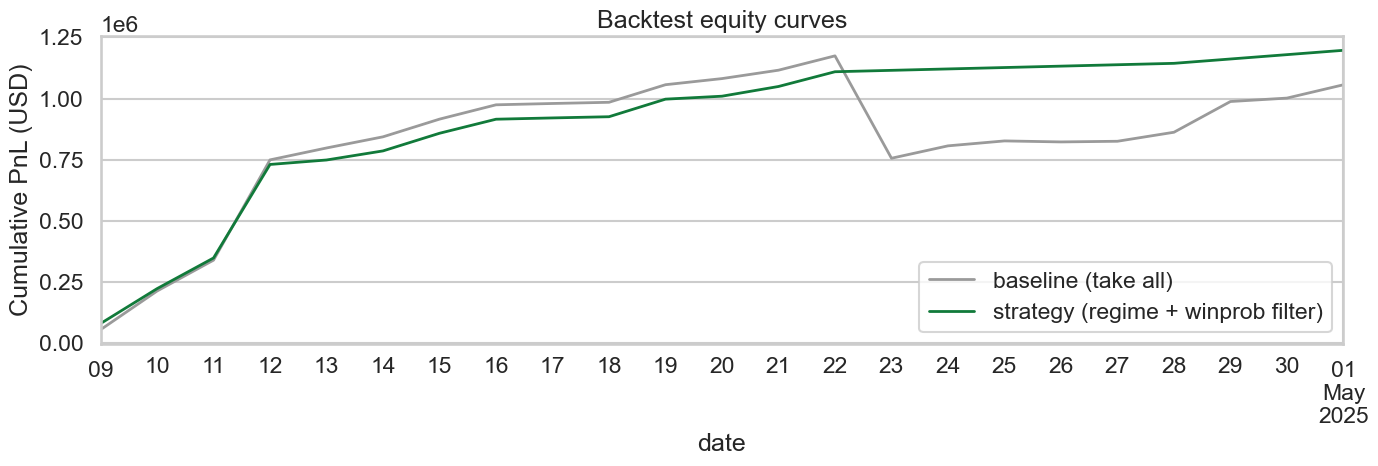

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
result.equity_baseline.plot(ax=ax, label='baseline (take all)', color='#9a9a9a', linewidth=2)
result.equity_strategy.plot(ax=ax, label='strategy (regime + winprob filter)', color='#117a3a', linewidth=2)
ax.set_title('Backtest equity curves')
ax.set_ylabel('Cumulative PnL (USD)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'backtest_equity.png', dpi=140)
plt.show()
plt.close('all')


## Sensitivity: vary min_winprob

In [5]:
rows = []
for mp in [0.50, 0.55, 0.60, 0.65, 0.70]:
    r = run_backtest(trades_test, proba_test, min_winprob=mp, exclude_regimes=[])
    rows.append({'min_winprob': mp, **r.to_summary()})
sens = pd.DataFrame(rows)
sens.to_csv(TBL_DIR / 'backtest_sensitivity.csv', index=False)
sens


,min_winprob,taken_trades,total_trades,pnl_strategy,pnl_baseline,uplift_pct,sharpe_strategy,sharpe_baseline,mdd_strategy,mdd_baseline
0,0.50,19700,20881,1040334.00,1056505.12,-1.53,6.512,6.622,-419161.26,-419020.23
1,0.55,19376,20881,993634.05,1056505.12,-5.95,6.386,6.622,-420430.65,-419020.23
2,0.60,18853,20881,961293.42,1056505.12,-9.01,6.208,6.622,-418226.86,-419020.23
3,0.65,17955,20881,921175.74,1056505.12,-12.81,6.015,6.622,-420883.73,-419020.23
4,0.70,16818,20881,905333.10,1056505.12,-14.31,6.078,6.622,-399075.49,-419020.23
